# Transformaciones Avanzadas con NumPy y Pandas

Este notebook demuestra las técnicas de **vectorización y broadcasting de NumPy**, junto con **agregaciones complejas de Pandas** (`groupby` y `merge`).

En lugar de usar loops tradicionales sobre el dataset, aplicamos operaciones matemáticas de forma masiva sobre arreglos enteros.

### Módulos del proyecto (`/src`)
Las funciones están centralizadas en la carpeta `/src` para promover la **reutilización de código** y la **modularidad**:

| Módulo | Responsabilidad |
|---|---|
| `limpieza.py` | Normalización de fechas, estandarización de categorías |
| `transformaciones.py` | Vectorización NumPy: conversión de moneda, IVA, outliers IQR |
| `agregaciones.py` | Groupby complejos, merge/join, índice de gravedad |

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Añadir /src al path para importar módulos propios del proyecto
sys.path.append('../src')
from limpieza import normalizar_fecha, estandarizar_sexo, estandarizar_triage
from transformaciones import (
    convertir_a_usd,
    calcular_costo_con_iva,
    calcular_estadisticas,
    detectar_outliers_iqr
)
from agregaciones import (
    resumen_costo_por_region,
    top_causas_por_pacientes,
    resumen_demografico_triage,
    calcular_indice_gravedad,
    merge_con_complementario
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Carga del dataset
df = pd.read_csv('../data/urgencias_noprocesados_grupo08.csv', encoding='latin-1')
print(f"Dataset cargado: {df.shape[0]:,} filas, {df.shape[1]} columnas")

Dataset cargado: 4,742 filas, 29 columnas


---
## Parte 1: Limpieza de Datos usando Módulos de `/src`

Aplicamos las funciones del módulo `limpieza.py` directamente sobre las columnas del DataFrame usando `.apply()`.  
Cada función encapsula la lógica de validación y estandarización, evitando duplicar código entre notebooks.

In [2]:
# Normalizar fechas (con .apply para mapear la función sobre cada celda)
df['FechaNormalizada'] = df['FechaAtencionTexto'].apply(normalizar_fecha)

# Estandarizar columnas categóricas
df['SexoEstandarizado']   = df['SexoPaciente'].apply(estandarizar_sexo)
df['TriageEstandarizado'] = df['PrioridadTriage'].apply(estandarizar_triage)

print("--- Comparación: Fecha original vs. Normalizada ---")
display(df[['FechaAtencionTexto', 'FechaNormalizada']].drop_duplicates().head(10))

print("\n--- Mapeo: SexoPaciente → SexoEstandarizado ---")
display(df.groupby(['SexoPaciente', 'SexoEstandarizado']).size().reset_index(name='Conteo'))

print("\n--- Mapeo: PrioridadTriage → TriageEstandarizado ---")
display(df.groupby(['PrioridadTriage', 'TriageEstandarizado']).size().reset_index(name='Conteo'))

--- Comparación: Fecha original vs. Normalizada ---


,FechaAtencionTexto,FechaNormalizada
0,02-01-2023,2023-01-02
1,02.01.23,2023-01-02
5,2023/01/02,NaN
30,09-01-2023,2023-01-09
31,2023/01/09,NaN
37,09.01.23,2023-01-09
60,2023/01/16,NaN
61,16-01-2023,2023-01-16
62,16.01.23,2023-01-16
90,23-01-2023,2023-01-23



--- Mapeo: SexoPaciente → SexoEstandarizado ---


,SexoPaciente,SexoEstandarizado,Conteo
0,F,F,2429
1,M,M,2267
2,SinDato,I,9
3,X,I,8
4,femenino,F,1
5,masculino,M,10



--- Mapeo: PrioridadTriage → TriageEstandarizado ---


,PrioridadTriage,TriageEstandarizado,Conteo
0,c2,C2,6
1,C-3,DESCONOCIDO,5
2,C1,C1,361
3,C2,C2,961
4,C3,C3,1555
5,C4,C4,1261
6,C4,C4,4
7,C5,C5,558
8,c1,C1,7
9,desconocido,DESCONOCIDO,6


---
## Parte 2: Transformaciones Avanzadas con NumPy

### ¿Por qué NumPy en lugar de un `for` loop?

Un loop tradicional en Python itera sobre cada fila individualmente. Con 50.000+ registros, esto es lento.
**NumPy vectoriza** la operación: aplica la transformación al arreglo completo en una sola instrucción a nivel de C, siendo cientos de veces más eficiente.

```python
# ❌ Lento (Python puro - loop)
resultado = [costo / 950 for costo in lista_costos]

# ✅ Rápido (NumPy - vectorización / broadcasting)
resultado = np.array(lista_costos) / 950
```

### 2.1 Broadcasting simple: Escalar sobre arreglo completo

In [3]:
# Extraer la columna de costos como arreglo NumPy
costos_clp = df['CostoAtencionCLP'].values

# --- Transformación 1: Broadcasting (escalar → arreglo completo) ---
# La tasa de cambio es un ESCALAR que NumPy "transmite" a todo el array sin loop
costos_usd = convertir_a_usd(costos_clp, tasa_cambio=950.0)
df['CostoUSD'] = costos_usd

# --- Transformación 2: Vectorización (IVA masivo) ---
# Aplica (1 + 0.19) a TODOS los elementos del array en una sola operación
costos_con_iva = calcular_costo_con_iva(costos_clp, tasa_iva=0.19)
df['CostoCLPconIVA'] = costos_con_iva

print("--- Muestra de las nuevas columnas transformadas ---")
display(df[['CostoAtencionCLP', 'CostoUSD', 'CostoCLPconIVA']].dropna().head(10))

--- Muestra de las nuevas columnas transformadas ---


,CostoAtencionCLP,CostoUSD,CostoCLPconIVA
0,126637.0,133.30,150698.0
1,48725.0,51.29,57983.0
2,112331.0,118.24,133674.0
3,104787.0,110.30,124697.0
4,78173.0,82.29,93026.0
5,97472.0,102.60,115992.0
6,125636.0,132.25,149507.0
7,113451.0,119.42,135007.0
8,121689.0,128.09,144810.0
9,129943.0,136.78,154632.0


### 2.2 Broadcasting con arreglo de tasas: Simulación de múltiples monedas

El **broadcasting avanzado** permite operar arreglos de distintas dimensiones.  
Aquí convertimos los costos a **4 monedas distintas simultáneamente** con una sola operación matricial:

```
costos (N,1)  /  tasas (1,4)  →  resultado (N,4)
```

Este patrón es imposible de replicar con loops simples de forma eficiente.

In [4]:
# Tasas de cambio aproximadas: CLP → [USD, EUR, GBP, BRL]
tasas = np.array([950.0, 1030.0, 1210.0, 190.0])   # shape: (4,)
monedas = ['USD', 'EUR', 'GBP', 'BRL']

# Filtrar solo registros con costo válido
costos_validos = df['CostoAtencionCLP'].dropna().values

# Broadcasting: reshape costos a columna (N, 1) y tasas a fila (1, 4)
# NumPy expande automáticamente las dimensiones al operar
costos_col = costos_validos.reshape(-1, 1)         # shape: (N, 1)
matriz_divisas = np.round(costos_col / tasas, 2)   # shape: (N, 4) — broadcasting!

# Convertir resultado a DataFrame para visualización
df_divisas = pd.DataFrame(matriz_divisas, columns=monedas)
df_divisas.insert(0, 'CostoOriginalCLP', costos_validos)

print("--- Broadcasting avanzado: Conversión a múltiples monedas (primeras 8 filas) ---")
print(f"Forma: costos {costos_col.shape} × tasas {tasas.shape} → resultado {matriz_divisas.shape}")
display(df_divisas.head(8))

--- Broadcasting avanzado: Conversión a múltiples monedas (primeras 8 filas) ---
Forma: costos (4724, 1) × tasas (4,) → resultado (4724, 4)


,CostoOriginalCLP,USD,EUR,GBP,BRL
0,126637.0,133.30,122.95,104.66,666.51
1,48725.0,51.29,47.31,40.27,256.45
2,112331.0,118.24,109.06,92.84,591.22
3,104787.0,110.30,101.73,86.60,551.51
4,78173.0,82.29,75.90,64.61,411.44
5,97472.0,102.60,94.63,80.56,513.01
6,125636.0,132.25,121.98,103.83,661.24
7,113451.0,119.42,110.15,93.76,597.11


### 2.3 Vectorización con máscara booleana: Detección y filtrado de outliers

NumPy permite crear **máscaras booleanas** aplicadas masivamente al arreglo completo.  
Esto reemplaza estructuras `if/else` anidadas dentro de loops.

In [5]:
# --- Estadísticas descriptivas con funciones NumPy vectorizadas ---
stats = calcular_estadisticas(costos_clp)

print("--- Estadísticas de CostoAtencionCLP (NumPy vectorizado) ---")
for k, v in stats.items():
    print(f"  {k:10}: $ {v:,.0f} CLP")

# --- Detección de Outliers con IQR (broadcasting: compara array vs escalares) ---
resultado_iqr = detectar_outliers_iqr(costos_clp)

print(f"\n--- Detección de Outliers (IQR con broadcasting NumPy) ---")
print(f"  Límite inferior : $ {resultado_iqr['limite_inferior']:>12,.0f} CLP")
print(f"  Límite superior : $ {resultado_iqr['limite_superior']:>12,.0f} CLP")
print(f"  N° de Outliers  : {resultado_iqr['n_outliers']:,} registros")

# Crear columna indicadora de outlier usando broadcasting vectorizado directamente en Pandas
li = resultado_iqr['limite_inferior']
ls = resultado_iqr['limite_superior']
df['EsOutlierCosto'] = (df['CostoAtencionCLP'] < li) | (df['CostoAtencionCLP'] > ls)
df['EsOutlierCosto'] = df['EsOutlierCosto'].fillna(False)

print(f"\n  Columna 'EsOutlierCosto' creada ({df['EsOutlierCosto'].sum()} outliers marcados).")

--- Estadísticas de CostoAtencionCLP (NumPy vectorizado) ---
  media     : $ 99,158 CLP
  mediana   : $ 97,942 CLP
  std       : $ 48,250 CLP
  min       : $ 15,000 CLP
  max       : $ 1,548,277 CLP

--- Detección de Outliers (IQR con broadcasting NumPy) ---
  Límite inferior : $       20,221 CLP
  Límite superior : $      175,104 CLP
  N° de Outliers  : 34 registros

  Columna 'EsOutlierCosto' creada (34 outliers marcados).


C:\Users\German\AppData\Local\Temp\ipykernel_13852\335000710.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


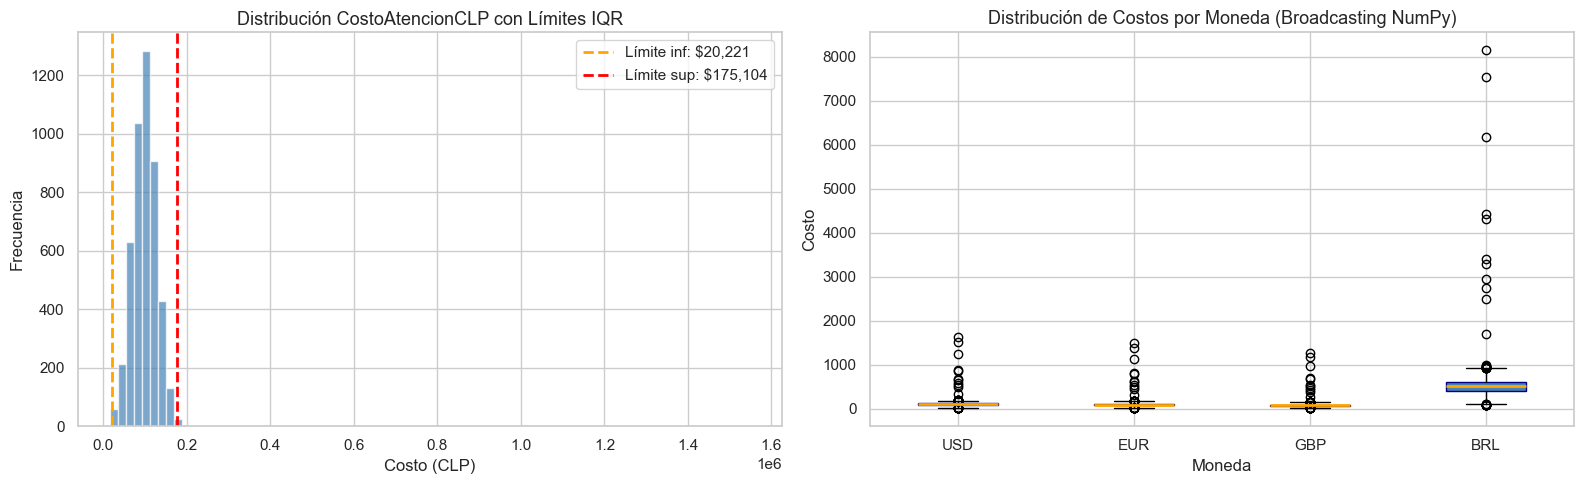

Gráfico guardado en outputs/numpy_transformaciones.png


In [6]:
# Visualización: Distribución de costos con límites IQR marcados
costos_sin_nan = costos_clp[~np.isnan(costos_clp)]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histograma con límites IQR
axes[0].hist(costos_sin_nan, bins=80, color='steelblue', alpha=0.7, edgecolor='white')
axes[0].axvline(resultado_iqr['limite_inferior'], color='orange', linestyle='--',
                linewidth=2, label=f"Límite inf: ${resultado_iqr['limite_inferior']:,.0f}")
axes[0].axvline(resultado_iqr['limite_superior'], color='red', linestyle='--',
                linewidth=2, label=f"Límite sup: ${resultado_iqr['limite_superior']:,.0f}")
axes[0].set_title('Distribución CostoAtencionCLP con Límites IQR', fontsize=13)
axes[0].set_xlabel('Costo (CLP)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Box plot de conversión multi-moneda
axes[1].boxplot(
    [df_divisas[m].dropna().values for m in monedas],
    labels=monedas,
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', color='navy'),
    medianprops=dict(color='orange', linewidth=2)
)
axes[1].set_title('Distribución de Costos por Moneda (Broadcasting NumPy)', fontsize=13)
axes[1].set_xlabel('Moneda')
axes[1].set_ylabel('Costo')

plt.tight_layout()
plt.savefig('../outputs/numpy_transformaciones.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado en outputs/numpy_transformaciones.png")

---
## Parte 3: Agregaciones Complejas con Pandas (`groupby`)

`groupby` permite calcular métricas segmentadas por una o más categorías. Es el equivalente de `GROUP BY` en SQL.

Las funciones están encapsuladas en `src/agregaciones.py`, lo que permite:
- Reutilizar la lógica en otros notebooks sin copiar código
- Mantener el notebook limpio y enfocado en la semántica del análisis
- Facilitar el testing unitario de las funciones de negocio

### 3.1 Costo de atención por región (groupby + múltiples agg)

In [7]:
# Función del módulo agregaciones.py: groupby con 4 métricas simultáneas
costo_por_region = resumen_costo_por_region(df)

print("--- Costo de Atención por Región (groupby con múltiples agg) ---")
display(costo_por_region)

--- Costo de Atención por Región (groupby con múltiples agg) ---


,RegionGlosa,Costo_Promedio,Costo_Mediana,Costo_Total,N_Registros
0,Metropolitana,100179.0,98089.0,189639409.0,1893
1,Arica y Parinacota,99274.0,97963.0,93317918.0,940
2,La Araucania,97799.0,98304.0,92811540.0,949
3,Valparaiso,98358.0,97184.0,92653129.0,942


### 3.2 Top 10 causas por total de pacientes atendidos

In [8]:
# Top causas con mayor carga de pacientes
atenciones_por_causa = top_causas_por_pacientes(df, n=10)

print("--- Top 10 Causas por Total de Pacientes Atendidos ---")
display(atenciones_por_causa)

--- Top 10 Causas por Total de Pacientes Atendidos ---


,Causa,Total_Pacientes,N_Registros
0,Influenza y neumonia,132744,787
1,COVID-19 sospecha/confirmada,129220,791
2,Bronquitis/Bronquiolitis aguda,124640,783
3,Crisis asmÃ¡tica,105760,794
4,Infeccion respiratoria aguda alta,104263,787
5,Insuficiencia respiratoria aguda,100698,773
6,Insuficiencia respirat0ria agudaa,1672,13
7,Bronquitis/Bronquiolitis agudaa,1266,7
8,Infeccion respirat0ria agudaa alta,1042,7


### 3.3 Análisis cruzado: Triage × Sexo (groupby de doble nivel)

In [9]:
# Groupby de dos variables: triage estandarizado x sexo estandarizado
demo_triage = resumen_demografico_triage(df)

print("--- Costo Promedio por Triage y Sexo (groupby 2 niveles) ---")
display(demo_triage)

--- Costo Promedio por Triage y Sexo (groupby 2 niveles) ---


,TriageEstandarizado,SexoEstandarizado,Costo_Promedio,N_Atenciones
0,C1,F,98640.0,188
1,C1,I,110414.0,4
2,C1,M,98587.0,176
3,C2,F,100783.0,477
4,C2,I,101004.0,5
5,C2,M,98552.0,483
6,C3,F,98417.0,779
7,C3,I,98066.0,12
8,C3,M,100790.0,757
9,C4,F,96979.0,676


### 3.4 Índice de Gravedad compuesto (groupby + NumPy broadcasting)

Esta función combina `groupby` de Pandas con vectorización de NumPy para calcular un indicador compuesto:  
**Índice de Gravedad = CostoNormalizado × PromediosPacientes**

La normalización se realiza aplicando broadcasting NumPy sobre la columna de resultados del groupby.

In [10]:
# Índice compuesto que combina groupby de Pandas + vectorización NumPy
indice = calcular_indice_gravedad(df)

print("--- Índice de Gravedad por Categoría de Triage ---")
display(indice)

--- Índice de Gravedad por Categoría de Triage ---


,TriageEstandarizado,Costo_Promedio,Pacientes_Promedio,N_Registros,Indice_Gravedad
0,C1,98742.902174,159.385870,368,157.91
1,C4,98644.891010,150.000000,1257,148.46
2,C2,99667.070466,146.874871,965,146.87
3,C5,98938.789946,146.353047,557,145.28
4,C3,99574.607235,144.641801,1548,144.51
5,DESCONOCIDO,91684.793103,147.931034,29,136.08


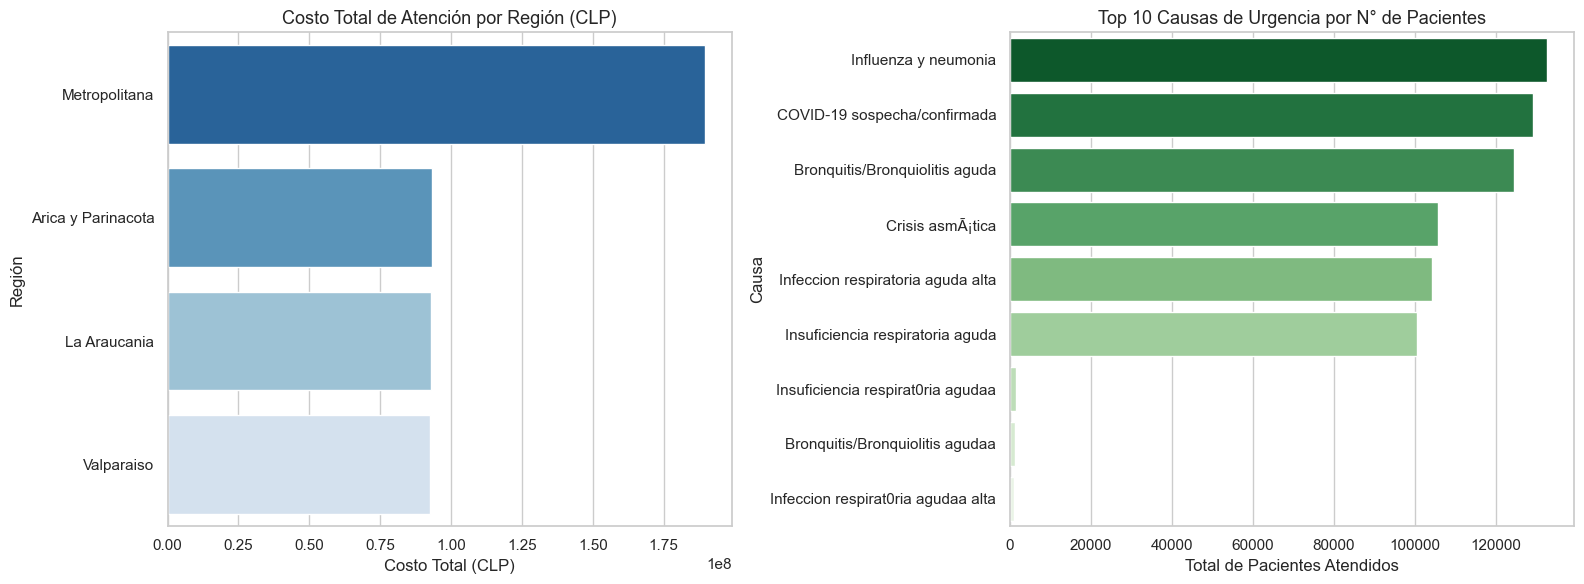

Gráfico guardado en outputs/graficos_groupby.png


In [11]:
# Visualización de los resultados de groupby
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Costo total por región (top 8)
top_regiones = costo_por_region.head(8)
sns.barplot(
    data=top_regiones,
    x='Costo_Total', y='RegionGlosa',
    palette='Blues_r', hue='RegionGlosa', legend=False, ax=axes[0]
)
axes[0].set_title('Costo Total de Atención por Región (CLP)', fontsize=13)
axes[0].set_xlabel('Costo Total (CLP)')
axes[0].set_ylabel('Región')

# Gráfico 2: Top causas por total pacientes
sns.barplot(
    data=atenciones_por_causa,
    x='Total_Pacientes', y='Causa',
    palette='Greens_r', hue='Causa', legend=False, ax=axes[1]
)
axes[1].set_title('Top 10 Causas de Urgencia por N° de Pacientes', fontsize=13)
axes[1].set_xlabel('Total de Pacientes Atendidos')
axes[1].set_ylabel('Causa')

plt.tight_layout()
plt.savefig('../outputs/graficos_groupby.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado en outputs/graficos_groupby.png")

---
## Parte 4: Merge / Join con Dataset Complementario

El **merge** de Pandas es el equivalente de un `JOIN` en SQL. Permite enriquecer el dataset principal con información de una fuente externa.

En este caso, creamos un dataset complementario con **clasificación de regiones** (zona geográfica y tipo de área) y lo unimos al dataset principal mediante un `LEFT JOIN`.

In [12]:
# Dataset complementario: clasificación geográfica de regiones de Chile
df_regiones = pd.DataFrame({
    'Region': [
        'Región de Tarapacá', 'Región de Antofagasta', 'Región de Atacama',
        'Región de Coquimbo', "Región de Valparaíso",
        "Región del Libertador Gral. Bernardo O'Higgins",
        'Región del Maule', 'Región del Biobío', 'Región de La Araucanía',
        'Región de Los Lagos',
        'Región de Aysén del Gral. Carlos Ibáñez del Campo',
        'Región de Magallanes y de La Antártica Chilena',
        'Región Metropolitana de Santiago', 'Región de Los Ríos',
        'Región de Arica y Parinacota', 'Región de Ñuble'
    ],
    'ZonaGeografica': [
        'Norte', 'Norte', 'Norte', 'Centro-Norte', 'Centro', 'Centro',
        'Centro-Sur', 'Centro-Sur', 'Sur', 'Sur', 'Austral', 'Austral',
        'Centro', 'Sur', 'Norte', 'Centro-Sur'
    ],
    'TipoArea': [
        'Urbana', 'Urbana', 'Mixta', 'Mixta', 'Urbana', 'Mixta',
        'Rural', 'Mixta', 'Rural', 'Mixta', 'Rural', 'Rural',
        'Metropolitana', 'Mixta', 'Urbana', 'Rural'
    ]
})

print("Dataset complementario de regiones:")
display(df_regiones)

Dataset complementario de regiones:


,Region,ZonaGeografica,TipoArea
0,Región de Tarapacá,Norte,Urbana
1,Región de Antofagasta,Norte,Urbana
2,Región de Atacama,Norte,Mixta
3,Región de Coquimbo,Centro-Norte,Mixta
4,Región de Valparaíso,Centro,Urbana
5,Región del Libertador Gral. Bernardo O'Higgins,Centro,Mixta
6,Región del Maule,Centro-Sur,Rural
7,Región del Biobío,Centro-Sur,Mixta
8,Región de La Araucanía,Sur,Rural
9,Región de Los Lagos,Sur,Mixta


In [13]:
# LEFT JOIN: enriquecer el dataset principal con la clasificación geográfica
df_enriquecido = merge_con_complementario(
    df_principal=df,
    df_complementario=df_regiones,
    key_left='RegionGlosa',
    key_right='Region',
    how='left'
)

# Verificar columnas nuevas
print("\n--- Columnas nuevas incorporadas por el merge ---")
print(df_enriquecido[['RegionGlosa', 'ZonaGeografica', 'TipoArea']].drop_duplicates())

# Análisis post-merge: costo promedio por Zona Geográfica
print("\n--- Costo Promedio por Zona Geográfica (post-merge groupby) ---")
costo_zona = (
    df_enriquecido.groupby('ZonaGeografica')['CostoAtencionCLP']
    .agg(Costo_Promedio='mean', N_Registros='count')
    .sort_values('Costo_Promedio', ascending=False)
    .reset_index()
)
costo_zona['Costo_Promedio'] = costo_zona['Costo_Promedio'].round(0)
display(costo_zona)

[merge] Filas antes: 4742 → después: 4742 (how='left')

--- Columnas nuevas incorporadas por el merge ---
           RegionGlosa ZonaGeografica TipoArea
0   Arica y Parinacota            NaN      NaN
6           Valparaiso            NaN      NaN
12       Metropolitana            NaN      NaN
24        La Araucania            NaN      NaN

--- Costo Promedio por Zona Geográfica (post-merge groupby) ---


,ZonaGeografica,Costo_Promedio,N_Registros


In [ ]:
print("=" * 60)
print("RESUMEN: Transformaciones avanzadas completadas")
print("=" * 60)
nuevas_cols = [
    'FechaNormalizada', 'SexoEstandarizado', 'TriageEstandarizado',
    'CostoUSD', 'CostoCLPconIVA', 'EsOutlierCosto'
]
print("  Columnas nuevas añadidas:")
for c in nuevas_cols:
    print(f"    - {c}")
print(f"  Outliers detectados en CostoAtencionCLP : {df['EsOutlierCosto'].sum():,}")
print(f"  Registros en dataset enriquecido (merge): {len(df_enriquecido):,}")
print(f"  Módulos /src utilizados: limpieza, transformaciones, agregaciones")